# Oppimisprojekti 3: Transformer-mallit 
## Osa 1: Tekstigeneraattori - Transformer Text Generation
## The Picture of Dorian Gray — Oscar Wilde (1890)
Project Gutenberg text ID 174, public domain

Oppimisprojekti 3: Transformer-mallit

#### NEED TO ADD SMALL MODEL AND COMPARING

In [1]:
# ── Cell 1: Environment & imports ────────────────────────────────────────────
# Set backend BEFORE importing keras — cannot be changed afterwards.
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import numpy as np
import keras
import sentencepiece as spm
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"Keras version   : {keras.__version__}")
print(f"Keras backend   : {keras.config.backend()}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("WARNING: GPU not found — training will be slow on CPU!")

PyTorch version : 2.6.0+cu124
Keras version   : 3.13.2
Keras backend   : torch
CUDA available  : True


## Cell 2: Load text
Download plain-text UTF-8 from https://www.gutenberg.org/ebooks/174  
Remove the Project Gutenberg header/footer manually. File should start with *THE PICTURE OF DORIAN GRAY* and end at *THE END*.

In [2]:
with open('./pg174.txt', 'r', encoding='utf-8-sig') as f:
    text = f.read()

print(f"Text length : {len(text):,} characters")
print(f"First 200 chars:\n{text[:200]}")

Text length : 448,657 characters
First 200 chars:
The Project Gutenberg eBook of The Picture of Dorian Gray
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restric


## Cell 3: Train SentencePiece tokeniser
SentencePiece learns a subword vocabulary from the raw text using BPE (Byte-Pair Encoding).  
`vocab_size = 8000` is enough for English (Finnish needed 40 000 because of its many grammatical suffixes).  
**Run the training block once. After that, only the `sp.load(...)` line is needed.**

In [3]:
temp_file    = 'dorian_temp.txt'
model_prefix = 'dorian_sp'
vocab_size   = 8000

# Write text to a temp file that SentencePiece can read
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# ── Train (comment out after the first run) ───────────────────────────────
spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=0.9999,   # 1.0 needed for Finnish; 0.9999 fine for English
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)
print("SentencePiece model trained and saved.")
# ─────────────────────────────────────────────────────────────────────────

# Load the tokeniser
sp = spm.SentencePieceProcessor()
sp.load(f'{model_prefix}.model')

# Sanity check
test_text = "The picture of Dorian Gray"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenised example : {tokens}")
print(f"Vocabulary size   : {sp.get_piece_size()}")

SentencePiece model trained and saved.
Tokenised example : ['▁The', '▁picture', '▁of', '▁Dorian', '▁Gray']
Vocabulary size   : 8000


## Cell 4: Prepare training data
The text is tokenised into integer IDs, then cut into overlapping windows of length `seq_length + 1`.
- **Input** = `window[0 : seq_length]`
- **Target** = `window[1 : seq_length + 1]` ← shifted by one position

This is standard next-token prediction (language modelling).

In [4]:
seq_length = 64   # context window: how many tokens the model sees at once

pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces):,}")

sequences = []
for i in range(0, len(pieces) - seq_length):
    sequences.append(pieces[i : i + seq_length + 1])

sequences = np.array(sequences, dtype=np.int32)
inputs  = sequences[:, :-1]   # shape: (N, seq_length)
targets = sequences[:, 1:]    # shape: (N, seq_length)

print(f"Number of sequences : {len(sequences):,}")
print(f"Input shape         : {inputs.shape}")
print(f"Target shape        : {targets.shape}")

# 80 / 20 train–validation split (shuffled)
idx   = np.arange(len(sequences))
np.random.shuffle(idx)
split = int(0.8 * len(idx))

train_inputs,  train_targets  = inputs[idx[:split]],  targets[idx[:split]]
val_inputs,    val_targets    = inputs[idx[split:]],   targets[idx[split:]]

print(f"Train samples : {len(train_inputs):,}")
print(f"Val   samples : {len(val_inputs):,}")

Total tokens: 104,756
Number of sequences : 104,692
Input shape         : (104692, 64)
Target shape        : (104692, 64)
Train samples : 83,753
Val   samples : 20,939


## Cell 5: Build the Transformer model
Architecture: **Embedding → Positional encoding → N × Transformer block → Linear head**

Each Transformer block:
1. Masked multi-head self-attention (causal mask = cannot look at future tokens)
2. Add & LayerNorm
3. Feed-forward network (two Dense layers)
4. Add & LayerNorm

In [5]:
def get_positional_encoding(max_len, d_model):
    """Sinusoidal positional encoding (Vaswani et al., 2017).
    Gives each position a unique pattern so the model can distinguish token order.
    """
    positions = np.arange(max_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / (10000 ** (dims / d_model))
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return angles   # shape: (max_len, d_model)


def create_causal_mask(size):
    """Lower-triangular mask — token i can only attend to positions <= i.
    Without this, the model could read future tokens during training,
    making generation impossible at inference time.
    """
    return 1 - np.triu(np.ones((size, size)), k=1)


# ── Hyperparameters ────────────────────────────────────────────────────────
embed_dim  = 256   # dimension of token embeddings and all hidden states
num_heads  = 4     # parallel attention heads (embed_dim must be divisible by num_heads)
ff_dim     = 512   # feed-forward sublayer width (typically 2 × embed_dim)
num_layers = 3     # number of stacked Transformer blocks
# ──────────────────────────────────────────────────────────────────────────

model_inputs    = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(model_inputs)

pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

causal_mask = create_causal_mask(seq_length)

for _ in range(num_layers):
    # Multi-head self-attention
    attn_out = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(x, x, attention_mask=causal_mask)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    # Feed-forward sublayer
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation='relu'),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1),
    ])
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn(x))

model_outputs = keras.layers.Dense(sp.get_piece_size())(x)

model = keras.Model(inputs=model_inputs, outputs=model_outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 64)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 64, 256)           │       2,048,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 64, 256)           │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 64, 256)           │         263,168 │ add[0][0], add[0][0]       │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 64, 256)           │               0 │ add[0][0],                 │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 64, 256)           │             512 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential (Sequential)       │ (None, 64, 256)           │         262,912 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 64, 256)           │               0 │ layer_normalization[0][0], │
│                               │                           │                 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 64, 256)           │             512 │ add_2[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 64, 256)           │         263,168 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_3 (Add)                   │ (None, 64, 256)           │               0 │ layer_normalization_1[0][… │
│                               │                           │                 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 64, 256)           │             512 │ add_3[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_1 (Sequential)     │ (None, 64, 256)           │         262,912 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 5,685,312 (21.69 MB)

 Trainable params: 5,685,312 (21.69 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 5b: Count trainable parameters
Useful for the report when comparing model sizes.

In [6]:
total_params     = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_variables)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Approx. model size   : {total_params * 4 / 1e6:.1f} MB  (float32)")

Total parameters     : 5,685,312
Trainable parameters : 5,685,312
Approx. model size   : 22.7 MB  (float32)


## Cell 6: Train
**Callbacks:**
- `EarlyStopping` — stops if val_loss stops improving (prevents overfitting)
- `ReduceLROnPlateau` — halves learning rate when progress stalls
- `ModelCheckpoint` — saves the best checkpoint to disk

In [7]:
batch_size = 64
epochs     = 10

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1, verbose=1),
        keras.callbacks.ModelCheckpoint(
            'dorian_best_model.keras', save_best_only=True, verbose=1
        ),
    ],
)

Epoch 1/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1103 - loss: 5.9920
Epoch 1: val_loss improved from None to 3.15883, saving model to dorian_best_model.keras

Epoch 1: finished saving model to dorian_best_model.keras
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 135s 103ms/step - accuracy: 0.1953 - loss: 4.8567 - val_accuracy: 0.3427 - val_loss: 3.1588 - learning_rate: 3.0000e-04
Epoch 2/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4178 - loss: 2.6875
Epoch 2: val_loss improved from 3.15883 to 1.17159, saving model to dorian_best_model.keras

Epoch 2: finished saving model to dorian_best_model.keras
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 129s 98ms/step - accuracy: 0.5108 - loss: 2.1899 - val_accuracy: 0.7306 - val_loss: 1.1716 - learning_rate: 3.0000e-04
Epoch 3/10
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7750 - loss: 0.9781
Epoch 3: val_loss improved from 1.17159 to 0.40313, saving model to dorian_best_model.keras

Epoch 3: finished saving model to dorian

## Cell 7: Plot training curves
Loss decreasing = model is learning.  
If train loss drops but val loss rises → **overfitting** → need more data, smaller model, or more dropout.

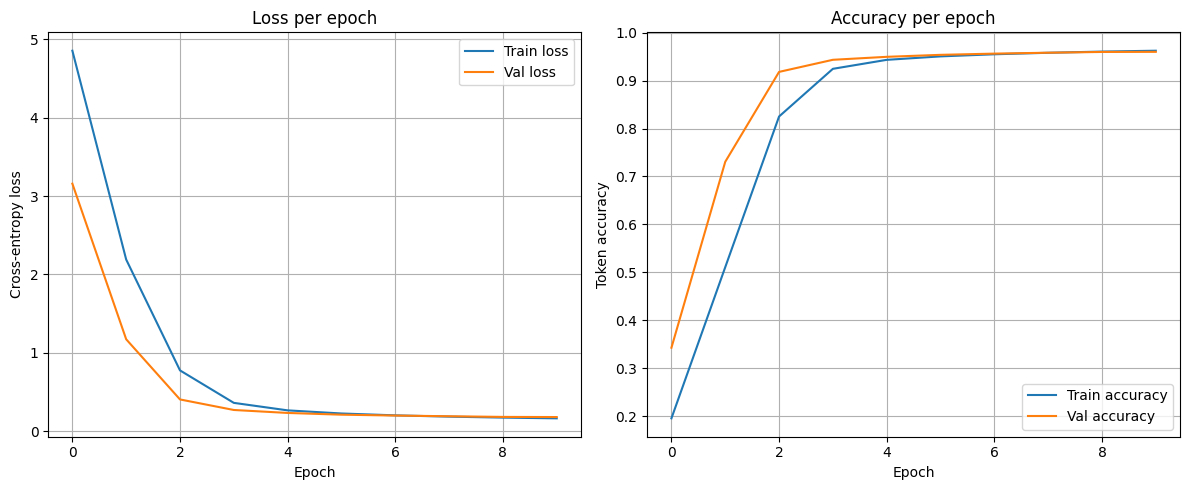

Plot saved as dorian_training_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Token accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('dorian_training_curves.png', dpi=150)
plt.show()
print("Plot saved as dorian_training_curves.png")

## Cell 8: Save the model

In [9]:
model.save('dorian_model.keras')
print("Model saved as 'dorian_model.keras'")

Model saved as 'dorian_model.keras'


## Cell 9: Text generation function
Autoregressive generation: at each step, feed the current context window to the model, sample the next token, append it, and slide the window forward.

**Temperature** controls how peaked the probability distribution is:
- `temperature → 0` : always picks the most probable token (repetitive but coherent)
- `temperature = 1.0` : samples from the true distribution
- `temperature > 1.0` : flattens distribution → more random / creative

In [10]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """Generate text autoregressively from a text prompt.

    Args:
        model       : trained Keras model
        sp          : SentencePiece tokeniser
        prompt      : starting string
        num_tokens  : how many new tokens to generate
        temperature : sampling temperature (see cell description above)

    Returns:
        Generated string decoded from token IDs
    """
    input_ids = sp.encode_as_ids(prompt)

    # Pad to seq_length if the prompt is shorter
    if len(input_ids) < seq_length:
        padding   = [0] * (seq_length - len(input_ids))
        input_ids = padding + input_ids
        pad_len   = len(padding)
    else:
        input_ids = input_ids[-seq_length:]
        pad_len   = 0

    generated_ids = list(input_ids[pad_len:])

    for _ in range(num_tokens):
        x          = np.array([input_ids])
        logits     = model.predict(x, verbose=0)[0, -1]   # last position only
        logits     = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))       # numerically stable softmax
        probs      = exp_logits / exp_logits.sum()
        next_token = np.random.choice(len(probs), p=probs)

        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    return sp.decode(generated_ids)

## Cell 10: Generate text — experiment with temperatures
Same prompt at different temperatures shows how the hyperparameter affects creativity vs. coherence.

In [11]:
prompts = [
    "The picture of Dorian Gray",
    "Lord Henry smiled",
    "Dorian felt a strange",
    "There is only one",
]

temperatures = [0.5, 1.0, 1.5]

for prompt in prompts:
    print(f"\n{'='*60}")
    print(f"PROMPT: {prompt}")
    print('='*60)
    for temp in temperatures:
        print(f"\n  [temperature = {temp}]")
        generated = generate_text(model, sp, prompt, num_tokens=100, temperature=temp)
        print(f"  {generated}")


PROMPT: The picture of Dorian Gray

  [temperature = 0.5]
  The picture of Dorian Gray had disappeared. When he looked back, the woman had vanished also. CHAPTER XVII. A week later Dorian Gray was sitting in the conservatory at Selby Royal, talking to the pretty Duchess of Monmouth, who with her husband, a jaded-looking man of sixty, was amongst his guests. It was tea-time, and the mellow light of the huge, lace-covered lamp that stood on the table lit up the delicate china and hammered silver of the service at which the duchess was pres

  [temperature = 1.0]
  The picture of Dorian Gray was infused by a Jewish doctor; Sigismondo Malatesta, the lover of Isotta and the lord of Rubinstein played, white hands on the Street of the room, oak-panelled hall of entrance, lights were still burning from three flickering jets: thin blue petals of flame they seemed, rimmed with white fire. He turned them out and, having thrown his hat and cape on the table, passed through the library towards the

## Cell 11: Load saved model (new session)
Run this cell instead of cells 5–8 if the model is already trained and saved.

In [12]:
# Load model and tokeniser
model = keras.models.load_model('dorian_model.keras')

sp = spm.SentencePieceProcessor()
sp.load('dorian_sp.model')

# Quick generation test
prompt    = "The soul of man"
generated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)
print(f"Prompt: {prompt}\n")
print(generated)

Prompt: The soul of man

The soul of man was said.” “Good-bye, my son,” she answered with a bow of strained stateliness. She was extremely annoyed at the tone he had adopted with her, and there was something in his look that had made her feel afraid. “Kiss me, Mother,” said the girl. Her flowerlike lips touched the withered cheek and warmed its frost. “My child! my child!” cried Mrs. Vane, looking up to the ceiling in search of an imaginary gallery. “Come, Sibyl,” said her brother impatiently. He hated his mother’s affectations. They went out into the flickering, wind-blown sunlight and strolled down the dreary Euston Road. The passersby glanced in wonder at the sullen heavy youth


## Cell 12: SUMMARY